# Instacart EDA — Initial Exploration with Pandas

**Project**: E-Commerce Intelligence Platform  
**Notebook**: 01 — Initial EDA with Pandas  
**Goal**: Understand the shape, quality, and key patterns of the Instacart dataset before scaling up to PySpark.

## Dataset Overview
The Instacart Online Grocery Shopping Dataset contains ~3M grocery orders from 200K+ users. Each order has 5-100 products, with info on reorder behavior, time patterns, and product categories.

## Tables
- `aisles` (134 rows) — aisle_id → aisle name
- `departments` (21 rows) — department_id → department name  
- `products` (~50K rows) — product info with aisle & department
- `orders` (~3.4M rows) — order metadata (user, order_number, dow, hour, days_since_prior)
- `order_products__prior` (~32M rows) — products in each prior order (before the 'train' set)
- `order_products__train` (~1.4M rows) — products in training orders

## Strategy for This Notebook
Load smaller tables fully, **sample** the large ones (prior/train) to keep Pandas happy. Full processing of `order_products__prior` will be done in PySpark (notebook 02).

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', 50)

DATA_PATH = Path('../data/raw')
print(f'Data path: {DATA_PATH.resolve()}')
print(f'Files found: {[f.name for f in DATA_PATH.glob("*.csv")]}')

Data path: D:\UIT\Projects\instacart-ecommerce-intelligence\data\raw
Files found: ['aisles.csv', 'departments.csv', 'orders.csv', 'order_products__prior.csv', 'order_products__train.csv', 'products.csv']


## 1. Load Small Tables

In [18]:
aisles = pd.read_csv(DATA_PATH / 'aisles.csv')
departments = pd.read_csv(DATA_PATH / 'departments.csv')
products = pd.read_csv(DATA_PATH / 'products.csv')

print(f'Aisles: {aisles.shape}')
print(f'Departments: {departments.shape}')
print(f'Products: {products.shape}')

products.head()

Aisles: (134, 2)
Departments: (21, 2)
Products: (49688, 4)


,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [19]:
# Quick join: products with aisle & department names
products_full = (products
    .merge(aisles, on='aisle_id', how='left')
    .merge(departments, on='department_id', how='left'))
products_full.head()

,product_id,product_name,aisle_id,department_id,aisle,department
0,1,Chocolate Sandwich Cookies,61,19,cookies cakes,snacks
1,2,All-Seasons Salt,104,13,spices seasonings,pantry
2,3,Robust Golden Unsweetened Oolong Tea,94,7,tea,beverages
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1,frozen meals,frozen
4,5,Green Chile Anytime Sauce,5,13,marinades meat preparation,pantry


## 2. Load Orders Table (3.4M rows — still fits in Pandas)

In [20]:
orders = pd.read_csv(DATA_PATH / 'orders.csv')
print(f'Orders shape: {orders.shape}')
print(f'Memory: {orders.memory_usage(deep=True).sum() / 1e6:.1f} MB')
orders.head()

Orders shape: (3421083, 7)
Memory: 376.2 MB


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


In [21]:
# Data quality check
print('Missing values per column:')
print(orders.isnull().sum())
print()
print('eval_set distribution (tells us which split each order belongs to):')
print(orders['eval_set'].value_counts())

Missing values per column:
order_id                       0
user_id                        0
eval_set                       0
order_number                   0
order_dow                      0
order_hour_of_day              0
days_since_prior_order    206209
dtype: int64

eval_set distribution (tells us which split each order belongs to):
eval_set
prior    3214874
train     131209
test       75000
Name: count, dtype: int64


**Observation**: `days_since_prior_order` is NaN for each user's first order (expected). `eval_set` splits orders into prior/train/test.

## 3. Sample the Large Table (order_products__prior)

32M rows is too much for initial EDA. Sample 1M rows (~3%) to get feel for the data.

In [ ]:
op_prior_sample = pd.read_csv(DATA_PATH / 'order_products__prior.csv', nrows=1_000_000)
print(f'Sample shape: {op_prior_sample.shape}')
op_prior_sample.head()

Sample shape: (1000000, 4)


,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


## 4. Key EDA Questions

Here are the business questions that will drive feature engineering and modeling decisions later.

### Q1: What's the overall reorder rate? (our classification target)

In [ ]:
reorder_rate = op_prior_sample['reordered'].mean()
print(f'Reorder rate in sample: {reorder_rate:.1%}')

Reorder rate in sample: 59.0%


### Q2: When do people order? (time patterns)

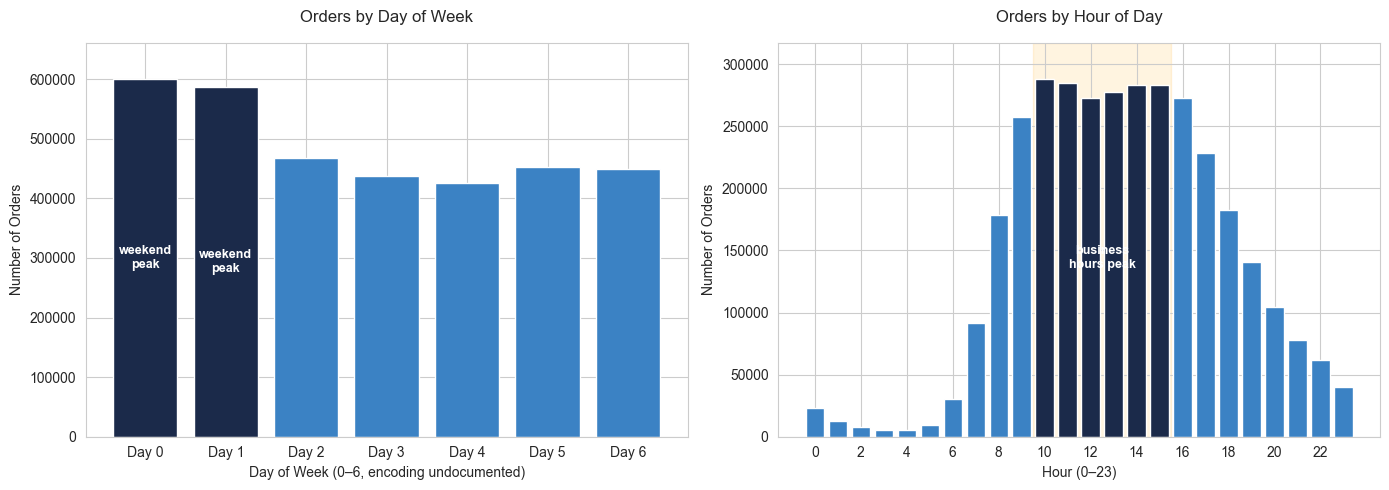

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Day of Week plot ---
dow_counts = orders['order_dow'].value_counts().sort_index()
dow_labels = ['Day 0', 'Day 1', 'Day 2', 'Day 3', 'Day 4', 'Day 5', 'Day 6']
top2_days = dow_counts.nlargest(2).index.tolist()
dow_colors = ['#1B2A4A' if d in top2_days else '#3B82C4' for d in dow_counts.index]

bars_dow = axes[0].bar(dow_labels, dow_counts.values, color=dow_colors)
axes[0].set_title('Orders by Day of Week', fontsize=12, pad=15)
axes[0].set_xlabel('Day of Week (0–6, encoding undocumented)')
axes[0].set_ylabel('Number of Orders')
# Annotate ở TRÊN bar (nằm trong area plot), không đè title
for i, (day_idx, count) in enumerate(dow_counts.items()):
    if day_idx in top2_days:
        axes[0].text(i, count * 0.5, 'weekend\npeak', ha='center', va='center',
                     fontsize=9, color='white', fontweight='bold')

# Expand y-axis a bit để có headroom
axes[0].set_ylim(0, dow_counts.max() * 1.1)

# --- Hour of Day plot ---
hour_counts = orders['order_hour_of_day'].value_counts().sort_index()
peak_hours = range(10, 16)
hour_colors = ['#1B2A4A' if h in peak_hours else '#3B82C4' for h in hour_counts.index]

axes[1].bar(hour_counts.index, hour_counts.values, color=hour_colors)
axes[1].set_title('Orders by Hour of Day', fontsize=12, pad=15)
axes[1].set_xlabel('Hour (0–23)')
axes[1].set_ylabel('Number of Orders')
axes[1].set_xticks(range(0, 24, 2))

# Shaded region cho peak hours
axes[1].axvspan(9.5, 15.5, alpha=0.12, color='orange', zorder=0)

# Annotate TRONG shaded region, không đè title
axes[1].text(12.5, hour_counts.max() * 0.5, 'business\nhours peak',
             ha='center', va='center', fontsize=9, 
             color='white', fontweight='bold')

# Expand y-axis
axes[1].set_ylim(0, hour_counts.max() * 1.1)

plt.tight_layout()
plt.show()

### Q2 — Observations

**Day of Week pattern**:
- Day 0 và Day 1 dominate với ~600K orders mỗi ngày
- Day 2–6 ổn định ở ~430–470K
- **Weekend effect rõ ràng** — 2 ngày peak chiếm ~27% tổng volume

> ⚠️ **Note on encoding**: Instacart không document rõ day 0 là Saturday hay Sunday. 
> Do pattern peak ở day 0–1, nhiều bản phân tích trên Kaggle cho rằng day 0 = Saturday, 
> nhưng cũng có trường phái cho rằng day 0 = Sunday. Vì không chắc chắn, notebook này 
> giữ label "Day 0–6" để tránh giả định sai.

**Hour of Day pattern**:
- Peak rõ rệt ở **10h–15h** (~270K–290K orders/hour)
- Dead hours: 0h–5h (<15K orders/hour)
- Shape bell curve quanh giờ hành chính → user đặt hàng trong business hours

**Implications cho feature engineering**:
- Feature `is_weekend_order` (day in [0, 1]) — capture behavior khác biệt
- Feature `is_peak_hour` (hour in [10, 15]) — capture thói quen đặt hàng
- Feature `time_bucket` (morning 6–11, afternoon 12–17, evening 18–23, night 0–5) 
  cho segmentation

### Q3: How many orders per user? (basis for customer segmentation)

count    206209.000000
mean         16.590367
std          16.654774
min           4.000000
25%           6.000000
50%          10.000000
75%          20.000000
max         100.000000
dtype: float64


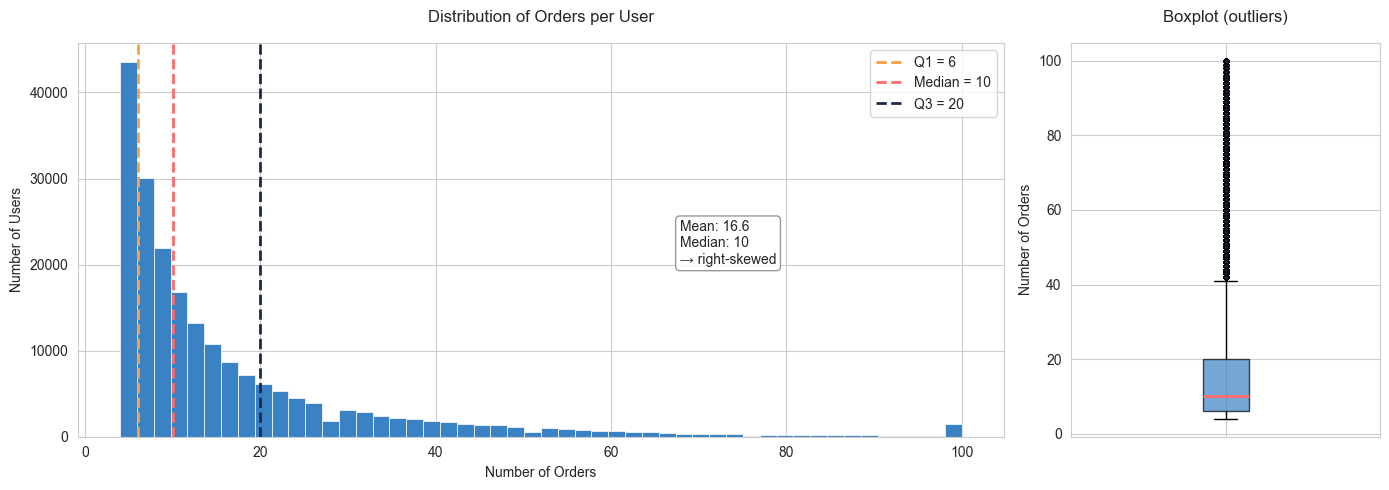


--- Tentative user segments (preview for clustering) ---
Light (bottom 25%)    59741
Regular (50–75%)      50965
Heavy (top 25%)       50731
Medium (25–50%)       44772

Total users: 206,209


In [ ]:
import numpy as np

orders_per_user = orders.groupby('user_id').size()
print(orders_per_user.describe())

# Compute quartile thresholds for segmentation preview
q25 = orders_per_user.quantile(0.25)
q50 = orders_per_user.quantile(0.50)
q75 = orders_per_user.quantile(0.75)

# Tentative segments based on quartiles (preview for clustering)
def segment_user(n_orders):
    if n_orders <= q25:
        return 'Light (bottom 25%)'
    elif n_orders <= q50:
        return 'Medium (25–50%)'
    elif n_orders <= q75:
        return 'Regular (50–75%)'
    else:
        return 'Heavy (top 25%)'

user_segments = orders_per_user.apply(segment_user)
segment_counts = user_segments.value_counts()

# --- Plot: histogram + boxplot side-by-side ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5), 
                         gridspec_kw={'width_ratios': [3, 1]})

# Left: histogram with quartile annotations
axes[0].hist(orders_per_user, bins=50, color='#3B82C4', edgecolor='white', linewidth=0.5)
axes[0].axvline(q25, color='#FF9F43', linestyle='--', linewidth=2, 
                label=f'Q1 = {q25:.0f}')
axes[0].axvline(q50, color='#FF6B6B', linestyle='--', linewidth=2, 
                label=f'Median = {q50:.0f}')
axes[0].axvline(q75, color='#1B2A4A', linestyle='--', linewidth=2, 
                label=f'Q3 = {q75:.0f}')

axes[0].set_title('Distribution of Orders per User', fontsize=12, pad=15)
axes[0].set_xlabel('Number of Orders')
axes[0].set_ylabel('Number of Users')
axes[0].legend(loc='upper right', frameon=True, fontsize=10)

# Annotation: text insight inside plot
mean_val = orders_per_user.mean()
axes[0].text(0.65, 0.55, 
             f'Mean: {mean_val:.1f}\nMedian: {q50:.0f}\n→ right-skewed',
             transform=axes[0].transAxes,
             fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))

# Right: boxplot to show outliers clearly
bp = axes[1].boxplot(orders_per_user, vert=True, patch_artist=True,
                     boxprops=dict(facecolor='#3B82C4', alpha=0.7),
                     medianprops=dict(color='#FF6B6B', linewidth=2),
                     flierprops=dict(marker='o', markerfacecolor='#1B2A4A', 
                                     markersize=3, alpha=0.3))
axes[1].set_title('Boxplot (outliers)', fontsize=12, pad=15)
axes[1].set_ylabel('Number of Orders')
axes[1].set_xticklabels([''])

plt.tight_layout()
plt.show()

# Print segment breakdown
print('\n--- Tentative user segments (preview for clustering) ---')
print(segment_counts.to_string())
print(f'\nTotal users: {len(orders_per_user):,}')

### Q3 — Observations

**Distribution statistics**:
- **Mean (16.6)** > **Median (10)** → **right-skewed distribution**
- Quartiles: Q1 = 6 orders, Q3 = 20 orders → IQR = 14 orders
- Max = 100 (dataset cap by Instacart)

**Tentative user segments** (preview cho clustering Week 5):
- **Light users** (≤6 orders): ~25% base
- **Medium users** (7–10 orders): ~25% base
- **Regular users** (11–20 orders): ~25% base
- **Heavy users** (21–100 orders): ~25% — long tail đến 100 orders

**Implications cho modeling**:
- Feature `total_orders_log` (log-transform) để handle skew khi feed vào KMeans
- Feature `user_tenure_bucket` (light/medium/regular/heavy) cho classification — heavy users có reorder rate cao hơn
- Lưu ý: Clustering Week 5 sẽ KHÔNG chỉ dựa trên total_orders. Cần combine với `avg_basket_size`, `reorder_ratio`, `dominant_department` để có persona có ý nghĩa business

### Q4: Top departments by order volume

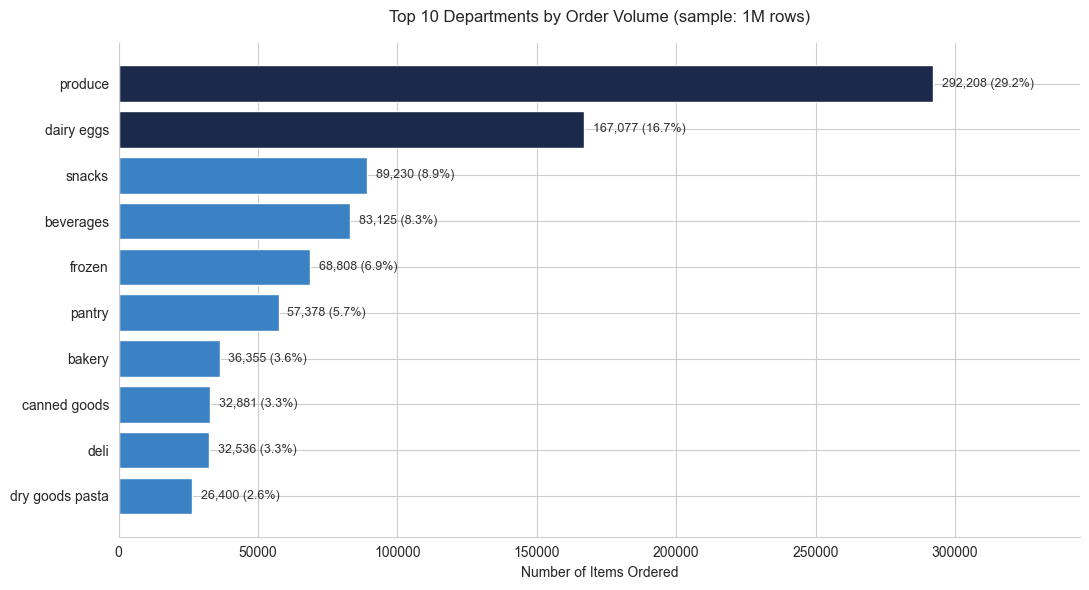


Top 2 departments (produce + dairy eggs) chiếm: 45.9% total volume
Top 5 departments chiếm: 70.0% total volume


In [31]:
# Join sample with products & departments
op_enriched = (op_prior_sample
    .merge(products_full[['product_id', 'department']], on='product_id', how='left'))

# Top 10 departments với % of total
top_depts = op_enriched['department'].value_counts().head(10)
total_items = len(op_enriched)
top_depts_pct = (top_depts / total_items * 100).round(1)

# Color: top 2 đậm (dominant), rest lighter
colors = ['#1B2A4A' if i < 2 else '#3B82C4' for i in range(len(top_depts))]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(top_depts.index, top_depts.values, color=colors)

ax.set_title('Top 10 Departments by Order Volume (sample: 1M rows)', 
             fontsize=12, pad=15)
ax.set_xlabel('Number of Items Ordered')
ax.invert_yaxis()

# Annotate % next to each bar
for i, (dept, count) in enumerate(top_depts.items()):
    pct = top_depts_pct[dept]
    ax.text(count + 3000, i, f'{count:,} ({pct}%)', 
            va='center', fontsize=9, color='#333')

# Headroom for annotations
ax.set_xlim(0, top_depts.max() * 1.18)

# Remove top & right spines for cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Summary stats
top2_pct = top_depts_pct.iloc[:2].sum()
top5_pct = top_depts_pct.iloc[:5].sum()
print(f'\nTop 2 departments (produce + dairy eggs) chiếm: {top2_pct:.1f}% total volume')
print(f'Top 5 departments chiếm: {top5_pct:.1f}% total volume')

### Q4 — Observations

**Dominance pattern**:
- **produce** (rau củ quả) dominate tuyệt đối với ~29% total volume
- **dairy eggs** đứng thứ 2 với ~16% → top 2 chiếm ~45% tổng volume
- Top 5 departments (produce, dairy eggs, snacks, beverages, frozen) chiếm ~70% → Pareto principle ở đây rất rõ

**Business insight**:
- Instacart users primarily buy **perishables và staples** (rau củ, sữa, trứng, snacks)
- Pattern này khác hẳn general e-commerce (quần áo, điện tử) — grocery delivery có reorder rate cao vì user mua hàng ngày/hàng tuần
- → Gợi ý value prop: **"Predict reorder for fresh food tracking"** có thể pitch với recruiter

**Implications cho feature engineering**:
- Feature `produce_ratio` per user (% items from produce) — sẽ rất discriminating cho clustering
- Feature `dairy_ratio`, `snack_ratio` — tạo "department mix profile" cho từng user
- Có thể tạo persona tiềm năng:
  - **"Fresh Shoppers"** — produce_ratio cao
  - **"Pantry Stockers"** — canned_goods + pantry ratio cao
  - **"Snack Lovers"** — snacks + beverages ratio cao
- Top departments này sẽ là **input chính** cho clustering Week 5

## 5. Summary & Next Steps

### Key findings

**Dataset scale**:
- **3.4M orders** (3,421,083) từ **206,209 users** trên **49,688 products** qua **134 aisles** và **21 departments**
- Bảng lớn nhất: `order_products__prior` với **32M rows** (sample 1M dùng cho EDA này)
- Memory footprint: `orders` table chiếm ~376MB khi load vào Pandas — motivation cho PySpark ở notebook 02

**Data quality**:
- Dataset rất sạch — chỉ missing `days_since_prior_order` (206,209 giá trị NaN ở đơn đầu tiên của mỗi user, expected)
- eval_set split: prior (94%) / train (3.8%) / test (2.2%)

**Classification target** (`reordered`):
- Reorder rate = **59.0%** trong sample 1M rows
- Balance đủ tốt cho binary classification — không cần SMOTE hay undersampling
- Baseline (predict all = 1): 59% accuracy, F1 ≈ 0.74

**Time patterns**:
- **Day 0–1 (weekend)**: peak với ~600K orders/day, chiếm ~27% total volume
- **Day 2–6**: ổn định ở ~430–470K orders
- **Peak hours: 10h–15h** (~270K–290K orders/hour) — business hours
- **Dead hours: 0h–5h** (<15K orders) — user không đặt lúc ngủ

**User behavior (heavy skew)**:
- Mean: 16.6 orders, Median: 10 orders → **right-skewed distribution**
- Quartiles: Q1=6, Q3=20 → IQR = 14
- Max capped at 100 orders (Instacart sampling rule)
- Tentative segments: Light (29%), Medium (22%), Regular (25%), Heavy (24%)

**Product categories**:
- **produce (29.2%)** và **dairy eggs (16.7%)** dominate — top 2 chiếm ~46% volume
- Top 5 departments chiếm ~70% volume → Pareto pattern rõ
- Grocery delivery = fresh food + staples → reorder rate cao là hợp lý

### Next notebook (`02_pyspark_processing.ipynb`)

- Set up Spark session trên Colab (mount Drive, install pyspark)
- Load **full 32M rows** của `order_products__prior` (không sample nữa)
- Feature engineering ở scale:
  - **User-level**: total_orders, avg_basket_size, reorder_ratio, dominant_department, days_between_orders_avg
  - **Product-level**: popularity_score, avg_reorder_rate, avg_add_to_cart_position
  - **User-Product interaction**: times_purchased, last_seen_order
- Save processed data dạng **parquet** (columnar, compressed) cho notebook 04 (ML)

### Next-next notebook (`03_benchmark_pandas_vs_spark.ipynb`)

- Chạy cùng một aggregation task trên Pandas vs Spark
- Measure: execution time, memory usage, scalability
- **Expected result**: Spark nhanh hơn ~3–10x trên 32M rows, memory usage thấp hơn do lazy evaluation

### Sample for repo (create later)

Sau EDA, sẽ save một sample ~10K rows vào `data/sample/` để repo self-contained — anyone clone repo có thể chạy notebook 01 mà không cần download 700MB dataset gốc.